In [1]:
import numpy as np
from matplotlib import pyplot as plt
import json
from pathlib import Path

### CRLB For Model Under Different Sensor Network Geometries

In [2]:
# This script computes the Cramer-Rao Lower Bound (CRLB) for a Time Difference of Arrival (TDOA) localization problem.

# TOA model
# t_arrival_i = t_emission + 1/c * sqrt((x_s-x_i)^2 + (y_s-y_i)^2) + noise_i 
# sensor index: i = 1, 2, 3, 4,
# time of signal emission: t_emission
# position of signal source: (x_s, y_s)
# speed of signal propagation: c

# NLS w/ Gauss-Newton Solution
def toa_solution_nls_gauss_newton(t_i, loc_rx, c, num_iter=4):
    source_estimate = np.array([1, 1, t_i[0]])#np.mean(loc_rx, axis=0)

    for _ in range(num_iter):
        t_residual = t_i - toa_model(loc_rx, source_estimate[:2], source_estimate[2], c)
        H, _ = toa_model_jacobian(loc_rx, source_estimate[:2], c)
        d_loc_src = np.linalg.pinv(H.T @ H) @ H.T @ t_residual
        source_estimate = source_estimate + d_loc_src
    return source_estimate

# Seperable Least-Squares Solution
def toa_solution_seperable_least_squares(t_i, loc_rx, c, sigma, num_iter=4):
    source_loc = np.array([1, 1]) # predict location

    for _ in range(num_iter):
        D = np.linalg.norm(loc_rx - source_loc, axis=1) # find distance for each sensor
        t_e = t_i - D/c # analytically compute time of emission for each sensor

        t_e_mean = np.dot(t_e, 1/sigma**2) / np.sum(1/sigma**2) # build variance weighted average

        residuals = t_i - (t_e_mean + D/c)
        H, _ = toa_model_jacobian(loc_rx, source_loc, c) 
        H = H[:, :2]  # drop dt_e term
        d_loc_src = np.linalg.pinv(H.T @ H) @ H.T @ residuals
        source_loc = source_loc + d_loc_src
    return source_loc

def toa_model(r_loc, s_loc, t_e, c):
    x_s, y_s = s_loc
    toa = []
    for x_i, y_i in r_loc:
        toa.append(t_e + (1/c) * np.linalg.norm([x_s - x_i, y_s - y_i]))
    return np.array(toa)

def toa_model_jacobian(r_loc, s_loc, c, sigma=None):
    jacobians = []
    x_s, y_s = s_loc
    for x_i, y_i in r_loc:
        D = np.linalg.norm([x_s-x_i, y_s-y_i])
        dt_dx = (x_s - x_i)/(c*D)
        dt_dy = (y_s - y_i)/(c*D)
        dt_dt = np.ones_like(dt_dx)
        jacobians.append(np.array([dt_dx, dt_dy, dt_dt]))

    if sigma is not None:
        R_inv = np.diag(1/np.array(sigma)**2)
    else:
        R_inv = None
    return np.array(jacobians), R_inv

# TDOA model
# tdoa_i = (1/c) * (sqrt((x_s-x_i)^2 + (y_s-y_i)^2) - sqrt((x_s-x_ref)^2 + (y_s-y_ref)^2)) + noise_i 
# sensor index: i = 1, 2, 3, 4,
# time of signal emission: t_emission
# position of signal source: (x_s, y_s)
# speed of signal propagation: c

# NLS w/ Gauss-Newton Solution
def tdoa_model_solution_nls_gauss_newton(t_i, loc_rx, c, sigma, num_iter=4):
    t_true = t_i[1:] - t_i[0]

    loc_src_est = np.array([2,-2])#np.mean(loc_rx[1:], axis=0)

    for _ in range(num_iter):
        t_residual = t_true - tdoa_model(loc_rx, loc_src_est, c)
        H, _ = tdoa_model_jacobian(loc_rx, loc_src_est, c)
        d_loc_src = np.linalg.pinv(H.T @ H) @ H.T @ t_residual
        loc_src_est = loc_src_est + d_loc_src

    # for each receiver, take distance  t_emissions = t_i - (1/c) * (rx to loc source)
    # take inverse var weighted average of t_emissions
    t_e = t_i - (1/c) * np.linalg.norm(loc_src_est - loc_rx, axis=1)
    t_emission = np.dot(t_e, 1/sigma**2) / np.sum(1/sigma**2)
    return loc_src_est, t_emission

def tdoa_model(loc_rx, loc_src, c):
    ref_t = (1/c) * np.linalg.norm(loc_src - loc_rx[0], axis=0)
    tdoa = (1/c) * np.linalg.norm(loc_src - loc_rx[1:], axis=1) - ref_t
    return tdoa

def tdoa_model_jacobian(r_loc, s_loc, c, sigma=None):
    ref = (1/c) * (s_loc - r_loc[0]) / np.linalg.norm(s_loc - r_loc[0])
    H = (1/c) * np.divide((s_loc - r_loc[1:]), np.linalg.norm(s_loc - r_loc[1:], axis=1)[:, None]) - ref
    
    # assumption: var(i) = sqrt(var(toa_i)**2 + var(toa_ref)**2)
    # this this assumption you can work out the matrix from Cov(e_i, e_j) = e_i * e_j, for e_i = var(i)
    # diags == var(i) ** 2, non diags == var(toa_ref) ** 2

    if sigma is not None:
        sigma_diag = (sigma[1:]**2 + sigma[0]**2)
        sigma_non_diag = sigma[0]**2
        diag = sigma_diag * np.eye(len(sigma)-1)
        non_diag = sigma_non_diag * (np.ones(len(sigma)-1) - np.eye(len(sigma)-1))
        R = diag + non_diag
        R_inv = np.linalg.pinv(R)
    else:
        R_inv = None
    return H, R_inv

In [3]:
def crlb(r_loc, s_loc, sigma, model_jacobian, c=343):
    H, R_inv = model_jacobian(r_loc, s_loc, c, sigma)
    FIM = H.T @ R_inv @ H
    CRLB = np.linalg.inv(FIM)
    return CRLB

def crlb_dir(s_loc, r_loc, c, sigma):
    x_s, y_s = s_loc
    I = np.zeros((3, 3))
    for (x_i, y_i), sig in zip(r_loc, sigma):
        D = np.sqrt((x_s-x_i)**2 + (y_s-y_i)**2)
        g = [(x_s - x_i)/(c*D), (y_s - y_i)/(c*D), 1]
        gg = np.outer(g, g)
        gg = gg * (1/(sig**2))
        I += gg
    return np.linalg.inv(I)

def plot_crlb(r_loc, sigma, model_jacobian, name):

    positions = []
    crlb_traces = []
    xs = np.linspace(-5, 5, 100)
    ys = np.linspace(-5, 5, 100)

    for x in xs:
        for y in ys:
            
            s_loc = (x, y)
            # CRLB = crlb_dir(s_loc, r_loc, 343, sigma)

            CRLB = crlb(r_loc, s_loc, sigma, model_jacobian, c=343)
            
            positions.append([x, y])
            crlb_traces.append(np.sqrt(np.trace(CRLB)))

    positions = np.array(positions)
    crlb_traces = np.array(crlb_traces)

    scatter = plt.scatter(positions[:, 0], positions[:, 1], c=crlb_traces, 
                        cmap='hot_r', s=20, vmin=0.0, vmax=2.0)
    plt.colorbar(scatter, label='Position Uncertainty (CRLB trace)')
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.title(f'CRLB vs Source Position\n({name})')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    plt.tight_layout()

def load_calibration_report(calibration_file):
    r_loc = []
    sigma = []
    toa = []
    calib_path = Path("output") / calibration_file
    with calib_path.open("r", encoding="utf-8") as f:
        calibration_report = json.load(f)
    for sensor in ["Sensor_0", "Sensor_1", "Sensor_2", "Sensor_3"]:
        r_loc.append((calibration_report[sensor]['x'], calibration_report[sensor]['y']))
        sigma.append(calibration_report[sensor]['pp_std'])
        if 'toa' in calibration_report[sensor]:
            toa.append(calibration_report[sensor]['toa'])
    if 'target_location' in calibration_report:
        target_location = [np.array([loc['x'], loc['y'], loc['timestamp']]) for loc in calibration_report['target_location']]
    else:
        target_location = None
    return np.array(r_loc), np.array(sigma), np.array(toa), np.array(target_location)


In [4]:
# Try Loading a Calibration Report
r_loc, sigma, toa, _ = load_calibration_report("calibration_report.json")

target_loc_tdoa = []
target_loc_toa_nls = []
target_loc_toa_separable = []
for i in range(toa.shape[1]):
    target_loc, _ = tdoa_model_solution_nls_gauss_newton(toa[:, i], r_loc, 343, sigma)
    target_loc_tdoa.append(target_loc)

    target_loc = toa_solution_nls_gauss_newton(toa[:, i], r_loc, 343)
    target_loc_toa_nls.append(target_loc)

    target_loc = toa_solution_seperable_least_squares(toa[:, i], r_loc, 343, sigma)
    target_loc_toa_separable.append(target_loc)

print(f'                   tdoa nls target loc: {np.abs(np.mean(np.array(target_loc_tdoa), axis=0)).sum()}, {np.std(np.array(target_loc_tdoa), axis=0).sum()}')
print(f'                    toa nls target loc: {np.abs(np.mean(np.array(target_loc_toa_nls)[:, :2], axis=0)).sum()}, {np.std(np.array(target_loc_toa_nls)[:, :2], axis=0).sum()}')
print(f'toa separable least squares target loc: {np.abs(np.mean(np.array(target_loc_toa_separable), axis=0)).sum()}, {np.std(np.array(target_loc_toa_separable), axis=0).sum()}')

                   tdoa nls target loc: 0.007965377558226443, 0.3610911519084673
                    toa nls target loc: 0.007656963985471818, 0.3642641588666985
toa separable least squares target loc: 0.007828924225704888, 0.36430850268092296


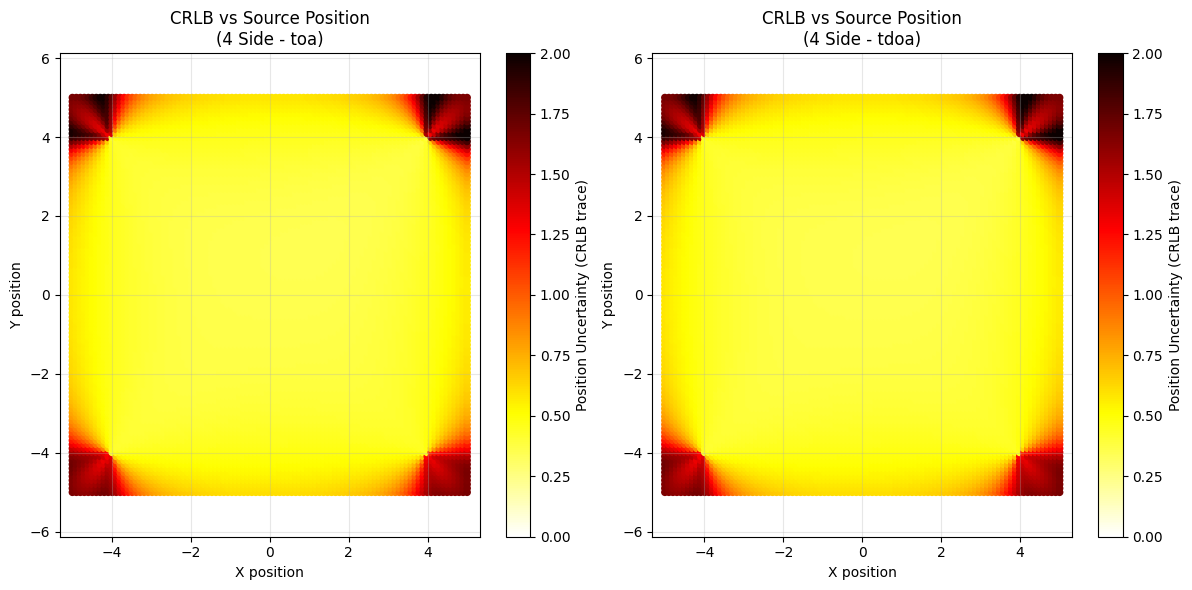

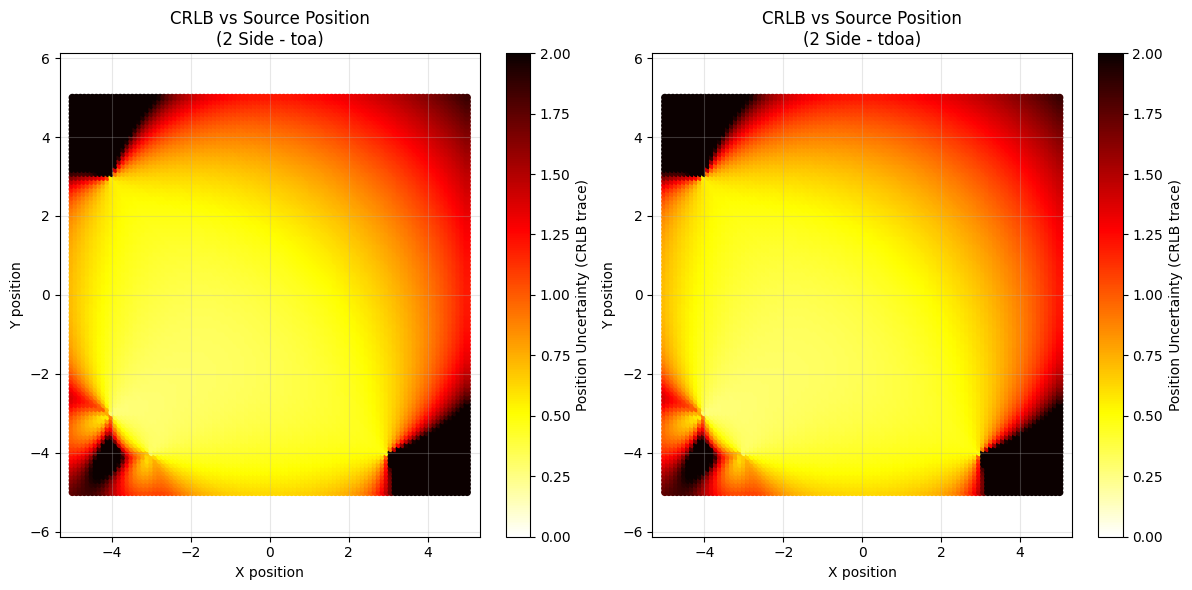

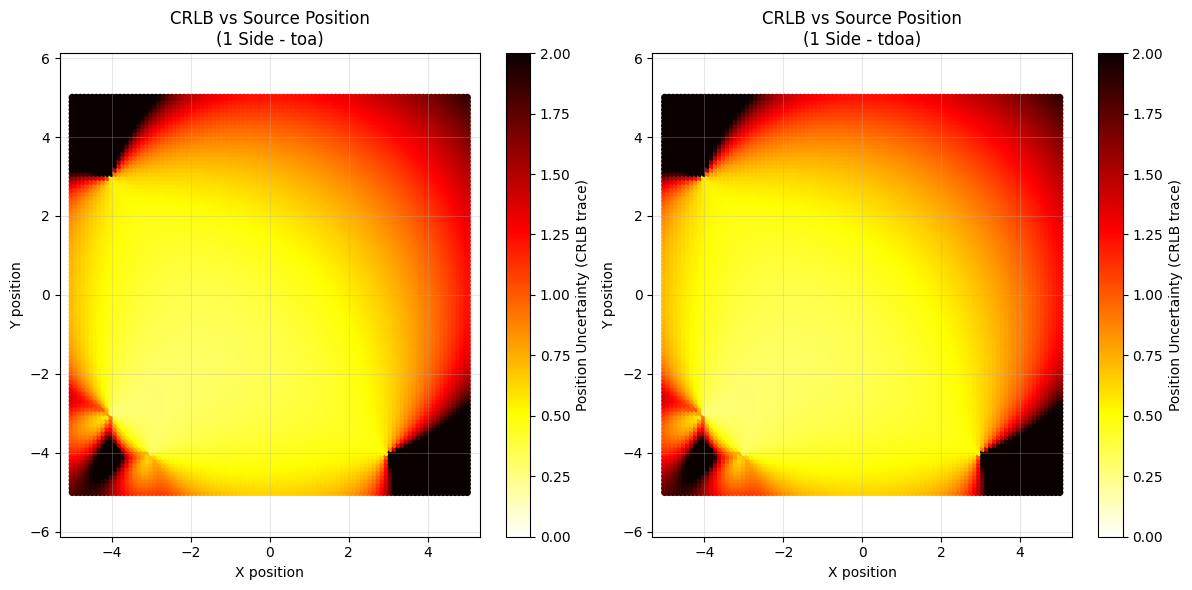

In [5]:
# CRLB Analysis of multiple sensor geometries

r_loc, sigma, _, _ = load_calibration_report("calibration_report_4_side.json")
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_crlb(r_loc, sigma, toa_model_jacobian, "4 Side - toa")
plt.subplot(122)
plot_crlb(r_loc, sigma, tdoa_model_jacobian, "4 Side - tdoa")
# print(sigma)

r_loc, sigma, _, _ = load_calibration_report("calibration_report_2_side.json")
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_crlb(r_loc, sigma, toa_model_jacobian, "2 Side - toa")
plt.subplot(122)
plot_crlb(r_loc, sigma, tdoa_model_jacobian, "2 Side - tdoa")

r_loc, sigma, _, _ = load_calibration_report("calibration_report_1_side.json")
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_crlb(r_loc, sigma, toa_model_jacobian, "1 Side - toa")
plt.subplot(122)
plot_crlb(r_loc, sigma, tdoa_model_jacobian, "1 Side - tdoa")

In [6]:
for errors, label in [
    (errors_tdoa, "TDOA NLS"),
    (errors_toa_nls, "TOA NLS"),
    (errors_toa_separable, "TOA Separable LS"),
]:
    e = np.sort(errors)
    cdf = np.arange(1, len(e) + 1) / len(e)
    plt.plot(e, cdf, label=label)

NameError: name 'errors_tdoa' is not defined

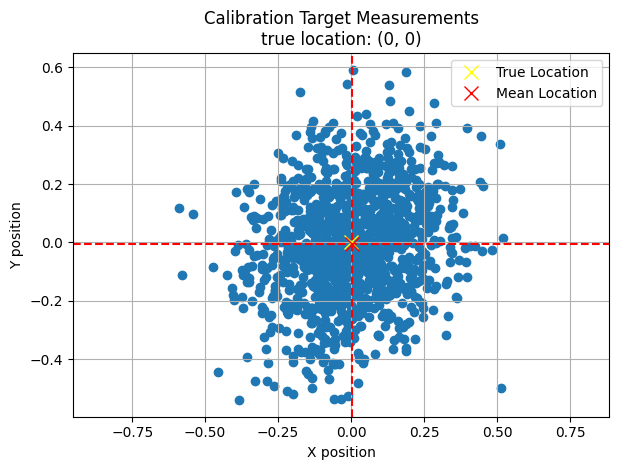

In [18]:
r_loc, sigma, toa, target = load_calibration_report("calibration_report.json")

x = target[:, 0]
y = target[:, 1]
timestamps = target[:, 2]

plt.scatter(x, y)
plt.axvline(np.mean(x), color="red", linestyle="--")
plt.axhline(np.mean(y), color="red", linestyle="--")
plt.plot([0], [0], "x", color="yellow", markersize=10, label="True Location")
plt.plot(np.mean(x), np.mean(y), "x", color="red", markersize=10, label="Mean Location")

plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Calibration Target Measurements\ntrue location: (0, 0)')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.legend()
plt.show()


array([0.35773766, 0.11214945, 0.40855499, ..., 0.09291645, 0.22435488,
       0.32447224], shape=(1200,))

57.2% of errors below 0.238 m
85.6% of errors below 0.357 m


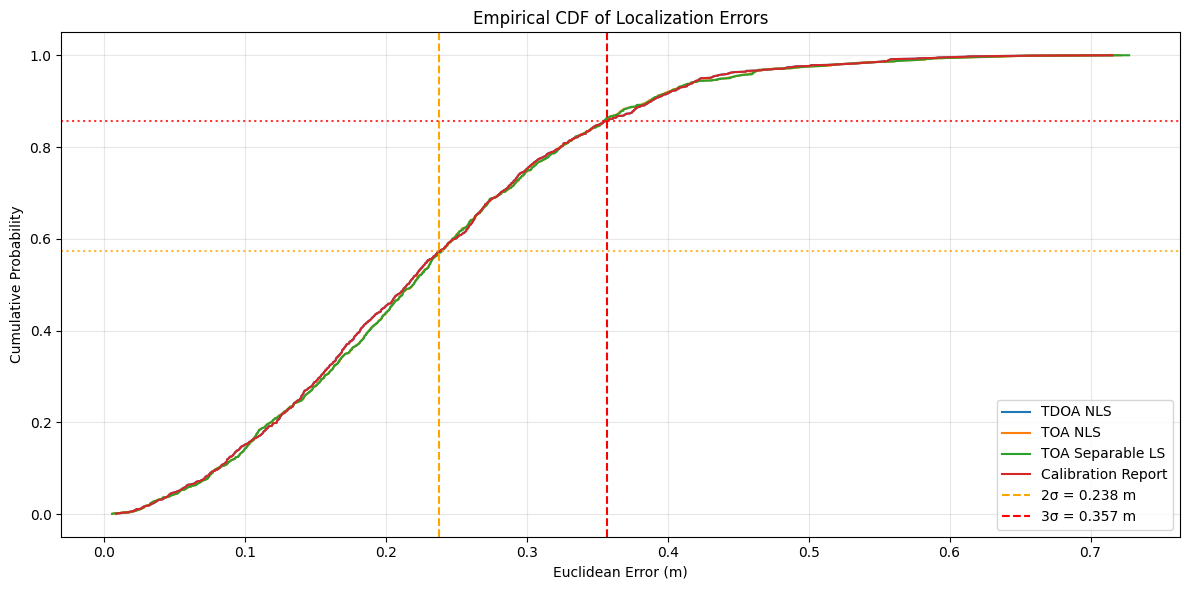

In [35]:
r_loc, sigma, toa, target_loc = load_calibration_report("calibration_report.json")

# Empirical CDFs
plt.figure(figsize=(12, 6))

errors_tdoa = np.linalg.norm(np.array(target_loc_tdoa) - np.array([0, 0]), axis=1)
errors_toa_nls = np.linalg.norm(np.array(target_loc_toa_nls)[:, :2] - np.array([0, 0]), axis=1)
errors_toa_separable = np.linalg.norm(np.array(target_loc_toa_separable) - np.array([0, 0]), axis=1)
error_report = np.linalg.norm(target_loc[:, :2] - np.array([0, 0]), axis=1)


for errors, label in [
    (errors_tdoa, "TDOA NLS"),
    (errors_toa_nls, "TOA NLS"),
    (errors_toa_separable, "TOA Separable LS"),
    (error_report, "Calibration Report")
]:
    e = np.sort(errors)
    cdf = np.arange(1, len(e) + 1) / len(e)
    plt.plot(e, cdf, label=label)

# Use TDOA error std to place 2σ and 3σ reference lines
sigma_err = np.std(error_report)
x_2sigma = 2 * sigma_err
x_3sigma = 3 * sigma_err

# CDF intersection values at 2σ and 3σ
cdf_2sigma = np.searchsorted(np.sort(error_report), x_2sigma, side="right") / len(error_report)
cdf_3sigma = np.searchsorted(np.sort(error_report), x_3sigma, side="right") / len(error_report)

plt.axvline(x_2sigma, color="orange", linestyle="--", label=f"2σ = {x_2sigma:.3f} m")
plt.axvline(x_3sigma, color="red", linestyle="--", label=f"3σ = {x_3sigma:.3f} m")
plt.axhline(cdf_2sigma, color="orange", linestyle=":", alpha=0.8)
plt.axhline(cdf_3sigma, color="red", linestyle=":", alpha=0.8)
# plt.plot([x_2sigma], [cdf_2sigma], "o", color="orange")
# plt.plot([x_3sigma], [cdf_3sigma], "o", color="red")

print(f'{cdf_2sigma*1e2:.1f}% of errors below {x_2sigma:.3f} m')
print(f'{cdf_3sigma*1e2:.1f}% of errors below {x_3sigma:.3f} m')

plt.title("Empirical CDF of Localization Errors")
plt.xlabel("Euclidean Error (m)")
plt.ylabel("Cumulative Probability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()